In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append('../scripts')

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
DATA_ROOT = '/data/a330d' #os.environ.get("DATA_ROOT", ".")
import numpy as np
import glob
import numpy as np
import json
import matplotlib as mpl
import re

from plotting import plot_model_comparison

/data/a330d/miniforge3/envs/cellina-graph/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
dataset_name = "merfish" # Options: merfish, crc

In [5]:
corr_dir = os.path.join(DATA_ROOT, f"datasets/{dataset_name}/correlations")
pattern = os.path.join(corr_dir, "*.json")
files = sorted(glob.glob(pattern))

rows = []
for fp in files:
    name = os.path.basename(fp)
    core = name[len("crc_"):-len(".json")] if dataset_name == "crc" else name[:-len(".json")]
    parts = core.split("_")
    sid = parts[0]
    model_name = parts[1]
    # If model_name contains a number, then continue otherwise skip
    if not re.search(r'\d', model_name):
        continue
    holdout_celltype = "_".join(parts[2:])
    try:
        with open(fp, "r") as f:
            data = json.load(f)
    except Exception:
        # skip unreadable/invalid json
        continue

    try:
        rows.append({
            "sid": f"crc_{sid}" if dataset_name == "crc" else sid,
            "model_name": model_name,
            "holdout_celltype": holdout_celltype,
            "n_deg": data.get("n_deg"),
            "spearman": data.get("spearman"),
            "pearson": data.get("pearson"),
            "precision": data.get("precision"),
            "direction_match": data.get("direction_match"),
            "direction_match_k": data.get("direction_match_k"),
            "direction_match_gt": data.get("direction_match_gt"),
            "mixing_index": data.get("mixing_index"),
            "edistance_global": data.get("edistance_global"),
            "edistance_local": data.get("edistance_local"),
            "edistance_pca": data.get("edistance_pca"),
            "edistance_pca_log": data.get("edistance_pca_log"),           
            "rmse": data.get("rmse"),
            "mse_lfc": data.get("mse_lfc"),
        })
    except Exception as e:
        print(f"Error processing file {fp}: {e}")
        continue

data_df = pd.DataFrame(rows)
data_df.head()

,sid,model_name,holdout_celltype,n_deg,spearman,pearson,precision,direction_match,direction_match_k,direction_match_gt,mixing_index,edistance_global,edistance_local,edistance_pca,edistance_pca_log,rmse,mse_lfc
0,C57BL6J-2.036,cellina-W-1-cf,GABAergic neuron_Fiber_tracts,50,0.870540,0.914610,0.62,1.000000,0.62,0.98,0.866848,40.097470,44.090670,690.544147,8.535579,842.119629,10.727286
1,C57BL6J-2.036,cellina-W-1-cf,GABAergic neuron_Isocortex,50,0.935078,0.972771,0.64,1.000000,0.64,1.00,0.701331,40.805359,44.339019,397.230850,9.382538,1319.698242,5.097899
2,C57BL6J-2.036,cellina-W-1-cf,astrocyte_Fiber_tracts,50,0.284226,0.470458,0.34,0.882353,0.30,0.70,0.576835,36.839698,36.999398,610.818726,7.696891,3955.918701,122.949661
3,C57BL6J-2.036,cellina-W-1-cf,astrocyte_Isocortex,50,0.884850,0.886652,0.50,1.000000,0.50,0.98,0.906251,39.668534,38.591734,371.862311,7.961316,3344.741455,10.312443
4,C57BL6J-2.036,cellina-W-1-cf,endothelial cell_Fiber_tracts,50,0.762209,0.994536,0.14,1.000000,0.14,0.78,0.933039,35.443476,35.453342,276.967090,6.514434,3950.766113,289.522278


In [6]:
# Remove -cf from the end of each model_name
data_df["model_name"] = data_df["model_name"].str.replace("-cf", "", regex=False)
n_deg = data_df["n_deg"].iloc[0]
data_df.head()

,sid,model_name,holdout_celltype,n_deg,spearman,pearson,precision,direction_match,direction_match_k,direction_match_gt,mixing_index,edistance_global,edistance_local,edistance_pca,edistance_pca_log,rmse,mse_lfc
0,C57BL6J-2.036,cellina-W-1,GABAergic neuron_Fiber_tracts,50,0.870540,0.914610,0.62,1.000000,0.62,0.98,0.866848,40.097470,44.090670,690.544147,8.535579,842.119629,10.727286
1,C57BL6J-2.036,cellina-W-1,GABAergic neuron_Isocortex,50,0.935078,0.972771,0.64,1.000000,0.64,1.00,0.701331,40.805359,44.339019,397.230850,9.382538,1319.698242,5.097899
2,C57BL6J-2.036,cellina-W-1,astrocyte_Fiber_tracts,50,0.284226,0.470458,0.34,0.882353,0.30,0.70,0.576835,36.839698,36.999398,610.818726,7.696891,3955.918701,122.949661
3,C57BL6J-2.036,cellina-W-1,astrocyte_Isocortex,50,0.884850,0.886652,0.50,1.000000,0.50,0.98,0.906251,39.668534,38.591734,371.862311,7.961316,3344.741455,10.312443
4,C57BL6J-2.036,cellina-W-1,endothelial cell_Fiber_tracts,50,0.762209,0.994536,0.14,1.000000,0.14,0.78,0.933039,35.443476,35.453342,276.967090,6.514434,3950.766113,289.522278


In [7]:
df = data_df.copy() # start with existing dataframe
df["sid"] = df["sid"].astype(str)

In [8]:
# Remove -W from model names
df["model_name"] = df["model_name"].str.replace("-W", "", regex=False)
df.model_name.unique()

array(['cellina-1', 'cellina-2', 'cpa-1', 'cpa-2', 'scgen-1', 'scgen-2'],
      dtype=object)

In [9]:
# Split model_name by '-' and add the last part as a new column 'seed'
df["seed"] = df["model_name"].str.split("-").str[-1]
df["model_name"] = df["model_name"].str.rsplit("-", n=1).str[0]

In [10]:
df

,sid,model_name,holdout_celltype,n_deg,spearman,pearson,precision,direction_match,direction_match_k,direction_match_gt,mixing_index,edistance_global,edistance_local,edistance_pca,edistance_pca_log,rmse,mse_lfc,seed
0,C57BL6J-2.036,cellina,GABAergic neuron_Fiber_tracts,50,0.870540,0.914610,0.62,1.000000,0.62,0.98,0.866848,40.097470,44.090670,690.544147,8.535579,842.119629,10.727286,1
1,C57BL6J-2.036,cellina,GABAergic neuron_Isocortex,50,0.935078,0.972771,0.64,1.000000,0.64,1.00,0.701331,40.805359,44.339019,397.230850,9.382538,1319.698242,5.097899,1
2,C57BL6J-2.036,cellina,astrocyte_Fiber_tracts,50,0.284226,0.470458,0.34,0.882353,0.30,0.70,0.576835,36.839698,36.999398,610.818726,7.696891,3955.918701,122.949661,1
3,C57BL6J-2.036,cellina,astrocyte_Isocortex,50,0.884850,0.886652,0.50,1.000000,0.50,0.98,0.906251,39.668534,38.591734,371.862311,7.961316,3344.741455,10.312443,1
4,C57BL6J-2.036,cellina,endothelial cell_Fiber_tracts,50,0.762209,0.994536,0.14,1.000000,0.14,0.78,0.933039,35.443476,35.453342,276.967090,6.514434,3950.766113,289.522278,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,C57BL6J-2.041,scgen,endothelial cell_Isocortex,50,0.859592,0.935010,0.64,1.000000,0.64,0.98,0.374996,6.500793,7.986438,1175.970825,1.823242,2023.291992,39.296463,2
176,C57BL6J-2.041,scgen,glutamatergic neuron_Fiber_tracts,50,0.409172,0.419003,0.02,1.000000,0.02,0.52,0.964858,12.918408,22.815159,798.195447,10.640639,9040.429688,15.868780,2
177,C57BL6J-2.041,scgen,glutamatergic neuron_Isocortex,50,0.669436,0.913734,0.16,1.000000,0.16,1.00,0.696909,13.044511,23.099547,846.152399,11.785520,12593.227539,18.105450,2
178,C57BL6J-2.041,scgen,oligodendrocyte_Fiber_tracts,50,0.180696,0.753265,0.16,1.000000,0.16,0.94,0.372380,3.913896,5.378552,1352.077759,1.508288,3780.251221,12.099734,2


In [11]:
old = pd.read_csv(f"../results/loo_summary_{dataset_name}_DEG_{n_deg}_v2.csv")

# Only keep model_name which exists in df
old = old[old["model_name"].isin(df["model_name"])]
old['seed'] = 0

In [14]:
# concat df and old
combined_df = pd.concat([df, old], ignore_index=True)

In [15]:
combined_df = combined_df.rename(columns={"direction_match_k": "signed_precision"})
combined_df = combined_df.rename(columns={"edistance_pca_log": "e-distance"})

In [16]:
combined_df['rmse'] = np.log10(combined_df['rmse'])
combined_df['rmse_lfc'] = np.sqrt(combined_df['mse_lfc'])

In [17]:
combined_df

,sid,model_name,holdout_celltype,n_deg,spearman,pearson,precision,direction_match,signed_precision,direction_match_gt,mixing_index,edistance_global,edistance_local,edistance_pca,e-distance,rmse,mse_lfc,seed,rmse_lfc
0,C57BL6J-2.036,cellina,GABAergic neuron_Fiber_tracts,50,0.870540,0.914610,0.62,1.000000,0.62,0.98,0.866848,40.097470,44.090670,690.544147,8.535579,2.925374,10.727286,1,3.275254
1,C57BL6J-2.036,cellina,GABAergic neuron_Isocortex,50,0.935078,0.972771,0.64,1.000000,0.64,1.00,0.701331,40.805359,44.339019,397.230850,9.382538,3.120475,5.097899,1,2.257853
2,C57BL6J-2.036,cellina,astrocyte_Fiber_tracts,50,0.284226,0.470458,0.34,0.882353,0.30,0.70,0.576835,36.839698,36.999398,610.818726,7.696891,3.597247,122.949661,1,11.088267
3,C57BL6J-2.036,cellina,astrocyte_Isocortex,50,0.884850,0.886652,0.50,1.000000,0.50,0.98,0.906251,39.668534,38.591734,371.862311,7.961316,3.524363,10.312443,1,3.211299
4,C57BL6J-2.036,cellina,endothelial cell_Fiber_tracts,50,0.762209,0.994536,0.14,1.000000,0.14,0.78,0.933039,35.443476,35.453342,276.967090,6.514434,3.596681,289.522278,1,17.015354
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,C57BL6J-2.041,scgen,endothelial cell_Isocortex,50,0.758175,0.938072,0.66,1.000000,0.66,1.00,0.337851,7.112005,8.950722,1310.473218,2.152319,3.319223,37.709442,0,6.140801
266,C57BL6J-2.041,scgen,glutamatergic neuron_Fiber_tracts,50,0.261753,0.301428,0.02,1.000000,0.02,0.48,0.821467,13.761540,23.216890,929.367639,11.437527,3.962318,17.067789,0,4.131318
267,C57BL6J-2.041,scgen,glutamatergic neuron_Isocortex,50,0.616038,0.872989,0.08,1.000000,0.08,0.98,0.679148,13.388599,23.484840,1007.666089,13.097571,4.112305,19.587717,0,4.425801
268,C57BL6J-2.041,scgen,oligodendrocyte_Fiber_tracts,50,0.057287,0.742869,0.16,1.000000,0.16,0.94,0.304157,4.431962,6.341003,1611.398413,1.788383,3.582113,12.781120,0,3.575069


In [18]:
grouping = "holdout_celltype"

# Define order
model_order = [
    "cpa",
    "scgen",
    "cellina",
]

default_palette = 'colorblind'
palette = default_palette

In [19]:
palette_dict = {
    'cellina': '#8172B2',
    'cellina-pert': '#8172B2',
    'cellina-ablated': "#BCB8C9",
    'cellina-gat': "#573BB1",
    'cellina-gat-pert': "#573BB1",
    'scgen':   'orange',
    'cpa':     "#8A5816",
    'mintflow':    'green',
    'spatialprop-pert': 'skyblue',
    'baseline':  'red',
}
palette = palette_dict

In [20]:
# Rename holdout_celltype by replacing the last '_' in with '-'
if dataset_name == "merfish":
    combined_df["holdout_celltype"] = combined_df["holdout_celltype"].str.replace("Fiber_tracts", "Fiber-tracts", regex=False)
else:
    combined_df["holdout_celltype"] = combined_df["holdout_celltype"].str.replace("T_cell", "T-cell", regex=False)

In [21]:
# Split holdout_celltype on '_' and place everything in [0] as holdout_celltype, and everything in [1:] as perturbation
combined_df["perturbation"] = combined_df["holdout_celltype"].apply(lambda x: "".join(x.split("_")[-1]) if len(x.split("_")) > 1 else "")
combined_df["holdout_celltype"] = combined_df["holdout_celltype"].apply(lambda x: "-".join(x.split("_")[:-1]))
combined_df

,sid,model_name,holdout_celltype,n_deg,spearman,pearson,precision,direction_match,signed_precision,direction_match_gt,mixing_index,edistance_global,edistance_local,edistance_pca,e-distance,rmse,mse_lfc,seed,rmse_lfc,perturbation
0,C57BL6J-2.036,cellina,GABAergic neuron,50,0.870540,0.914610,0.62,1.000000,0.62,0.98,0.866848,40.097470,44.090670,690.544147,8.535579,2.925374,10.727286,1,3.275254,Fiber-tracts
1,C57BL6J-2.036,cellina,GABAergic neuron,50,0.935078,0.972771,0.64,1.000000,0.64,1.00,0.701331,40.805359,44.339019,397.230850,9.382538,3.120475,5.097899,1,2.257853,Isocortex
2,C57BL6J-2.036,cellina,astrocyte,50,0.284226,0.470458,0.34,0.882353,0.30,0.70,0.576835,36.839698,36.999398,610.818726,7.696891,3.597247,122.949661,1,11.088267,Fiber-tracts
3,C57BL6J-2.036,cellina,astrocyte,50,0.884850,0.886652,0.50,1.000000,0.50,0.98,0.906251,39.668534,38.591734,371.862311,7.961316,3.524363,10.312443,1,3.211299,Isocortex
4,C57BL6J-2.036,cellina,endothelial cell,50,0.762209,0.994536,0.14,1.000000,0.14,0.78,0.933039,35.443476,35.453342,276.967090,6.514434,3.596681,289.522278,1,17.015354,Fiber-tracts
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,C57BL6J-2.041,scgen,endothelial cell,50,0.758175,0.938072,0.66,1.000000,0.66,1.00,0.337851,7.112005,8.950722,1310.473218,2.152319,3.319223,37.709442,0,6.140801,Isocortex
266,C57BL6J-2.041,scgen,glutamatergic neuron,50,0.261753,0.301428,0.02,1.000000,0.02,0.48,0.821467,13.761540,23.216890,929.367639,11.437527,3.962318,17.067789,0,4.131318,Fiber-tracts
267,C57BL6J-2.041,scgen,glutamatergic neuron,50,0.616038,0.872989,0.08,1.000000,0.08,0.98,0.679148,13.388599,23.484840,1007.666089,13.097571,4.112305,19.587717,0,4.425801,Isocortex
268,C57BL6J-2.041,scgen,oligodendrocyte,50,0.057287,0.742869,0.16,1.000000,0.16,0.94,0.304157,4.431962,6.341003,1611.398413,1.788383,3.582113,12.781120,0,3.575069,Fiber-tracts


In [22]:
combined_df_1 = combined_df[combined_df["perturbation"].str.contains("Isocortex")]
combined_df_2 = combined_df[combined_df["perturbation"].str.contains("Fiber-tracts")]

In [23]:
# Split celltype column on empty space and take the first part as new celltype column
combined_df_1["holdout_celltype"] = combined_df_1["holdout_celltype"].str.split(" ").str[0]
combined_df_2["holdout_celltype"] = combined_df_2["holdout_celltype"].str.split(" ").str[0]

/tmp/ipykernel_1390026/1516916574.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_1["holdout_celltype"] = combined_df_1["holdout_celltype"].str.split(" ").str[0]
/tmp/ipykernel_1390026/1516916574.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_df_2["holdout_celltype"] = combined_df_2["holdout_celltype"].str.split(" ").str[0]


In [24]:
metric_labels = {
    "pearson": r"Pearson $r$ ↑",
    "spearman": r"Spearman $\rho$ ↑",
    "signed_precision": r"Signed Precision ↑",
    "e-distance": r"E-distance ↓",
    "rmse": r"$\mathrm{RMSE}_{\mathrm{counts}}$ ↓",
    "rmse_lfc": r"$\mathrm{RMSE}_{\mathrm{LFC}}$ ↓"
}

In [49]:
from matplotlib.patches import Patch

def plot_model_comparison(
    dataset_name,
    df,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=False,
    save=False,
    save_path="../figures",
    save_name="ood_summary",
    hide=False,
    legend_only=False,
    metric_labels=None,
    source_domain=None,
    target_domain=None,
):
    hatch_map = {
    "cellina-pert": "///",
    "cellina-gat-pert": "///",
    "spatialprop-pert": "///",
    }

    if legend_only:
        fig = plt.figure(figsize=(6, 1))
        handles = [
            Patch(
                facecolor=palette[m],
                edgecolor="black" if m in hatch_map else "none",
                hatch=hatch_map[m] if m in hatch_map else "",
                label=m
            )
            for m in model_order
        ]
        fig.legend(handles, model_order, ncol=len(model_order), loc="center", fontsize=16)
        plt.axis("off")
        if save:
            plt.savefig(f"{save_path}/{save_name}.svg", format="svg", bbox_inches="tight")
        plt.show()
        return
    
    # Compute global y-limits
    ymin = df[metrics].min().min() * 0.3
    ymax = df[metrics].max().max() * 1.05

    fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 5))
    n_deg = df["n_deg"].iloc[0]    

    title = f"{dataset_name}: Performance for DEG {n_deg} ({source_domain} → {target_domain})"
    if hide:
        title = ""
    fig.suptitle(title, fontsize=20)

    # Ensure axes iterable if only one metric
    if len(metrics) == 1:
        axes = [axes]

    for ax, metric in zip(axes, metrics):
        if not average_only:
            # -------------------------------
            # Per-celltype plot
            # -------------------------------
            celltypes = df[grouping].unique().tolist()
            all_x_labels = list(celltypes)

            ymin = df[metric].min().min() * 0.3
            ymax = df[metric].max().max() * 1.05

            sns.barplot(
                data=df,
                x=grouping,
                y=metric,
                hue="model_name",
                estimator="mean",
                errorbar="se",
                hue_order=model_order,
                ax=ax,
                palette=palette,
                order=celltypes,
                dodge=True,
                width=.85,
            )

            for container, model in zip(ax.containers, model_order):
                if model in hatch_map:
                    for bar in container:
                        bar.set_hatch(hatch_map[model])
                        bar.set_linewidth(1.0)
            
            ax.legend_.remove()

            for container, model in zip(ax.containers, model_order):
                for bar in container:
                    
                    # always light grey border for base bars
                    bar.set_edgecolor("lightgrey")
                    bar.set_linewidth(0.8)

                    # if hatch model → overlay a hatch-only bar
                    if model in hatch_map:
                        ax.add_patch(
                            plt.Rectangle(
                                (bar.get_x(), bar.get_y()),
                                bar.get_width(),
                                bar.get_height(),
                                fill=False,
                                hatch=hatch_map[model],
                                edgecolor="black",   # hatch color
                                linewidth=0
                            )
                        )

            ax.set_xticks(range(len(all_x_labels)))
            ax.set_xticklabels(all_x_labels, rotation=20)
            ax.tick_params(axis="y", labelsize=12)
            ax.tick_params(axis="x", labelsize=12)
            ax.set_ylim(ymin, ymax)
        

        else:
            # -------------------------------
            # AVERAGE-ONLY plot (clean)
            # -------------------------------
            df_avg = (
                df.groupby(["model_name"])[metric]
                .agg(["mean", "sem"])
                .reset_index()
            )

            sns.barplot(
                data=df_avg,
                x="model_name",
                y="mean",
                hue="model_name",
                order=model_order,
                palette=palette,
                errorbar=None,  # we add manually
                ax=ax,
                width=.6,
            )

            # Add SE manually
            for i, model in enumerate(model_order):
                row = df_avg[df_avg.model_name == model].iloc[0]
                ax.errorbar(
                    x=i,
                    y=row["mean"],
                    yerr=row["sem"],
                    fmt="none",
                    capsize=0,
                    color="black",
                )

            #ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
            ax.tick_params(axis="x", rotation=45)

        # -------------------------------
        # Shared styling
        # -------------------------------
        
        label = metric_labels.get(metric, metric) if metric_labels else metric
        ax.set_title(label, fontsize=18)
        ax.set_xlabel("")
        ax.set_ylabel("")

    # -------------------------------
    # Global legend (only once)
    # -------------------------------
    if not average_only:
        handles, labels = axes[0].get_legend_handles_labels()
    else:
        handles = [
            plt.Rectangle((0, 0), 1, 1, color=palette[m])
            for m in model_order
        ]
        labels = model_order

    #if hide:
    # Set legend visible False
    handles = []
    labels = []
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.3)

    if save:
        plt.savefig(f"{save_path}/{save_name}.svg", bbox_inches="tight")
        plt.savefig(f"{save_path}/{save_name}.png", bbox_inches="tight")
    plt.show()

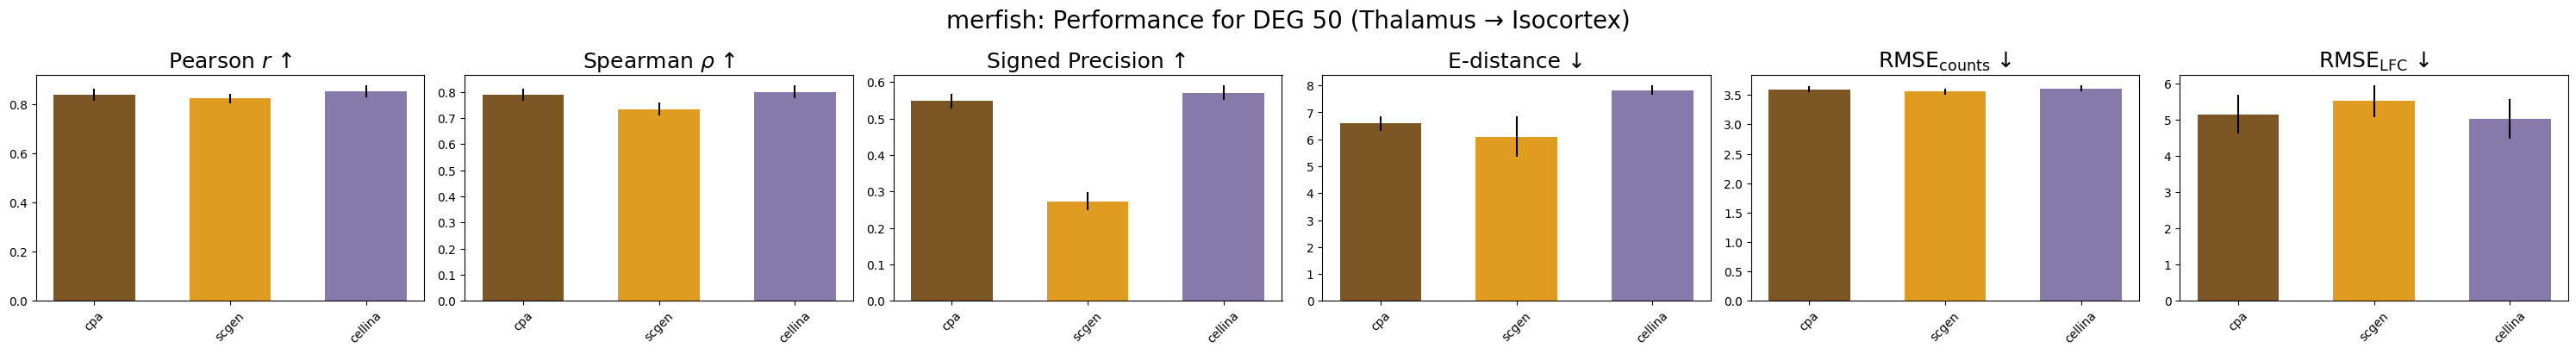

In [50]:
metrics = ["pearson", "spearman", "signed_precision", "e-distance", "rmse", "rmse_lfc"]
plot_model_comparison(
    dataset_name,
    combined_df_1,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=True,
    save=True,
    save_name=f"{dataset_name}_multiseed_Isocortex_1",
    hide=False,
    metric_labels=metric_labels,
    source_domain="Thalamus",
    target_domain="Isocortex",
)

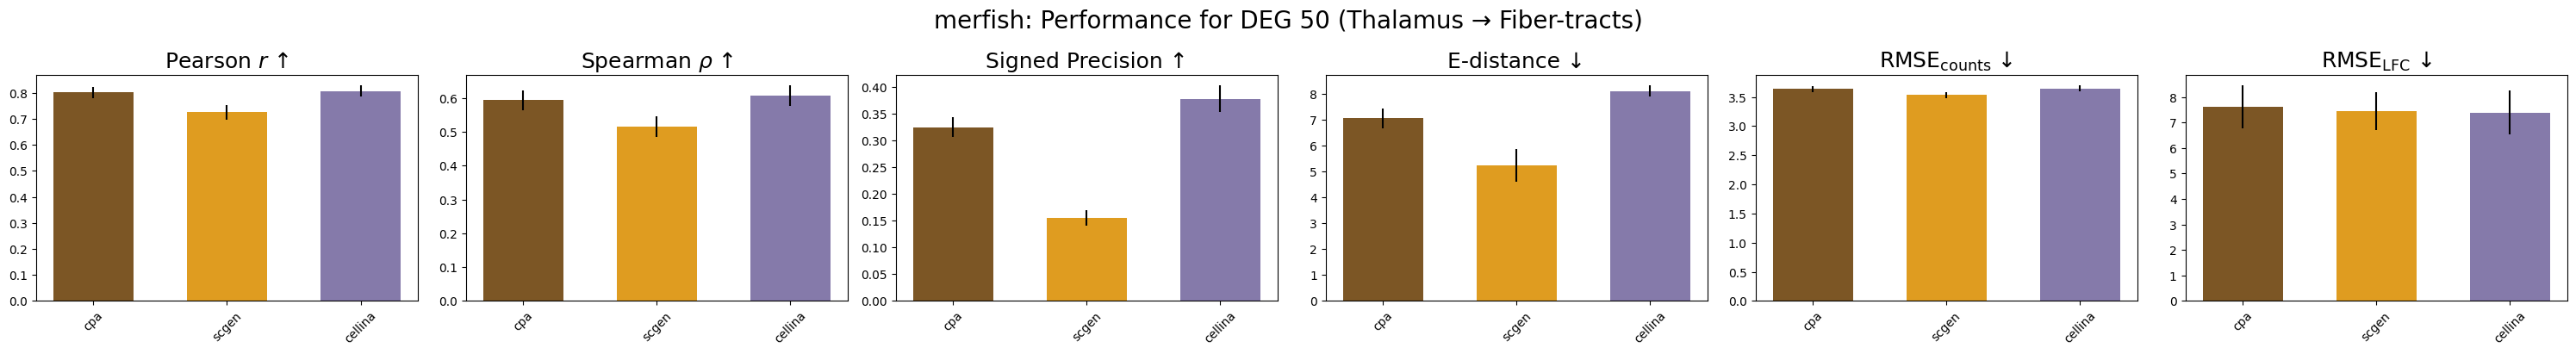

In [51]:
metrics = ["pearson", "spearman", "signed_precision", "e-distance", "rmse", "rmse_lfc"]
plot_model_comparison(
    dataset_name,
    combined_df_2,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=True,
    save=True,
    save_name=f"{dataset_name}_multiseed_Fiber-tracts_1",
    hide=False,
    metric_labels=metric_labels,
    source_domain="Thalamus",
    target_domain="Fiber-tracts",
)

In [ ]:
# Make df with only the mean and std over 'metrics' for each model_name
# The std should be over 'seed' column i.e. for each model I want to compare how much variability there is across seeds

combined_df_avg = combined_df.groupby("model_name")[metrics].agg(["mean", "std"]).reset_index()
combined_df_avg = combined_df_avg.round(2)
combined_df_avg

model_name pearson       spearman       signed_precision       e-distance  \
                mean   std     mean   std             mean   std       mean   
0    cellina    0.83  0.15     0.70  0.21             0.47  0.18       7.96   
1        cpa    0.82  0.16     0.69  0.20             0.44  0.17       6.82   
2      scgen    0.77  0.17     0.62  0.21             0.21  0.14       5.67   

         rmse       rmse_lfc        
    std  mean   std     mean   std  
0  1.28  3.62  0.35     6.21  4.92  
1  2.20  3.62  0.34     6.38  4.88  
2  4.64  3.55  0.35     6.48  4.15

In [57]:
# Make a df from combined_df which averages over celltype, sid and perturbation but keeps model_name and seed separate
combined_df_avg_seed = combined_df.groupby(["model_name", "seed"])[metrics].mean().reset_index()
combined_df_avg_seed = combined_df_avg_seed.round(2)
combined_df_avg_seed
# Compute mean and std of each metric for each model across seeds
combined_df_seed_summary = combined_df_avg_seed.groupby("model_name")[metrics].agg(["mean", "std"]).reset_index()
combined_df_seed_summary = combined_df_seed_summary.round(2)
combined_df_seed_summary

model_name pearson       spearman       signed_precision       e-distance  \
                mean   std     mean   std             mean   std       mean   
0    cellina    0.83  0.00     0.71  0.01             0.47  0.01       7.96   
1        cpa    0.82  0.00     0.69  0.01             0.43  0.01       6.82   
2      scgen    0.77  0.01     0.62  0.01             0.21  0.02       5.66   

         rmse       rmse_lfc        
    std  mean   std     mean   std  
0  0.04  3.63  0.01     6.21  0.03  
1  0.26  3.62  0.00     6.38  0.02  
2  0.11  3.55  0.01     6.48  0.05